In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import os, contextlib
from tqdm.auto import tqdm

from tamoc import ambient, dbm, seawater, single_bubble_model, dispersed_phases

import gasbubbles

In [2]:
# ============================================================
# User parameters — edit this cell and rerun cells below
# ============================================================

# Release conditions
z0 = 400.0          # release depth (m)
de = 1.0e-3          # initial bubble diameter (m)
T0 = 273.15 + 0.0   # release temperature (K); set None for ambient temp

# Gas composition and initial mole fractions (must sum to 1.0)
composition = ['methane', 'carbon_dioxide', 'oxygen', 'nitrogen']
mol_frac = np.array([0.93, 0.04, 0.0, 0.03])
#mol_frac = np.array([0.00, 0.00, 0.21, 0.79])
#mol_frac = np.array([1, 0.00, 0.0, 0.0])

# Mass transfer / dissolution controls
K = 0.035             # mass transfer reduction factor (--)
K_T = 1.0           # heat transfer reduction factor (--)
fdis = 1e-06         # dissolved fraction at which particle is "gone"
t_hyd = 0         # hydrate film formation time (s); 0 = dirty from start
lag_time = True      # include biodegradation lag time
delta_t = 3.0       # maximum ODE time step (s)

# Ambient: optional background methane concentration (kg/m^3)
# Set to None to skip adding methane to the ambient profile
methane_background_kg_m3 = 3.0e-6

In [3]:
# create ambient profile
profile = ambient.Profile(None)


# Optionally add background methane
if methane_background_kg_m3 is not None:
    z_pts = profile.interp_ds.coords['z'].values.astype(float)
    ch4_data = np.column_stack([z_pts, np.full_like(z_pts, methane_background_kg_m3)])
    profile.append(ch4_data, ['z', 'methane'], ['m', 'kg/m^3'],
                   comments=['coordinate', 'constant background methane'])
    
# Add equilibrium dissolved gas concentrations (N2, O2, Ar, CO2)
profile.add_computed_gas_concentrations()

In [6]:
# Create the gas bubble particle
gas = dbm.FluidParticle(composition, fp_type=0.)

# Initialize the single bubble model with the ambient profile
sbm = single_bubble_model.Model(profile)

# Run the simulation (suppress TAMOC's verbose print output)
with contextlib.redirect_stdout(open(os.devnull, 'w')):
    sbm.simulate(gas, z0, de, mol_frac, T0,
                 K=K, K_T=K_T, fdis=fdis, t_hyd=t_hyd,
                 lag_time=lag_time, delta_t=delta_t)

[Text(0.5, 0, 'Equivalent diameter (mm)'),
 Text(0, 0.5, 'Depth (m)'),
 Text(0.5, 1.0, 'Bubble size vs depth')]

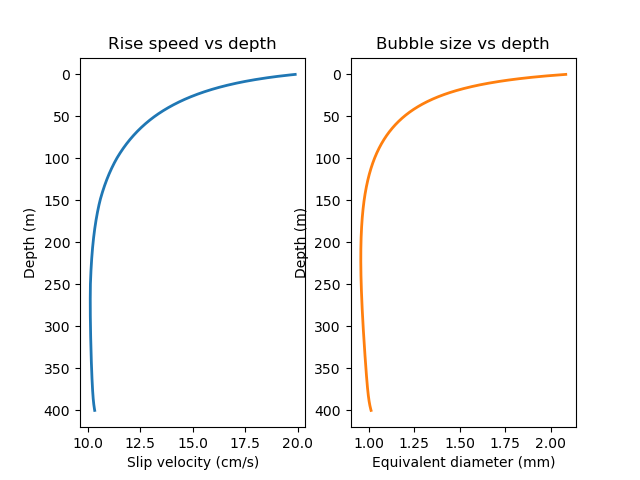

In [13]:
# Extract the derived variables from the simulation
data, var_names, n_chems = sbm.get_derived_variables(track_chems=composition)

# Show the available column names
# print("Columns returned by get_derived_variables():")
# for i, name in enumerate(var_names):
#     print(f"  [{i:2d}] {name}")

# Pull out key arrays for plotting
t = data[:, var_names.index('Simulation time (s)')]
z = data[:, var_names.index('Particle z-coordinate (m)')]
us = data[:, var_names.index('Slip velocity (m/s)')]
de_out = data[:, var_names.index('Particle diameter (m)')]
m_total = data[:, var_names.index('Total mass of all compounds in particle (kg)')]

#print(f"\nSimulation: {t[-1]:.1f} s, bubble reached {z[-1]:.1f} m depth")

plt.close('comp')
fig,(ax1,ax2) = plt.subplots(num='comp', ncols=2)

ax1.plot(1e2*us, z, lw=2)
ax1.invert_yaxis()
ax1.set(xlabel='Slip velocity (cm/s)', ylabel='Depth (m)',
              title='Rise speed vs depth')

ax2.plot(1e3 * de_out, z, lw=2, c='tab:orange')
ax2.invert_yaxis()
ax2.set(xlabel='Equivalent diameter (mm)', ylabel='Depth (m)',
              title='Bubble size vs depth')
#fig.show()

  0%|          | 0/1223 [00:00<?, ?it/s]

[Text(0.5, 0, 'Rise speed (cm/s)'),
 Text(0, 0.5, 'Depth (m)'),
 Text(0.5, 1.0, 'Bubble rise speed vs depth')]

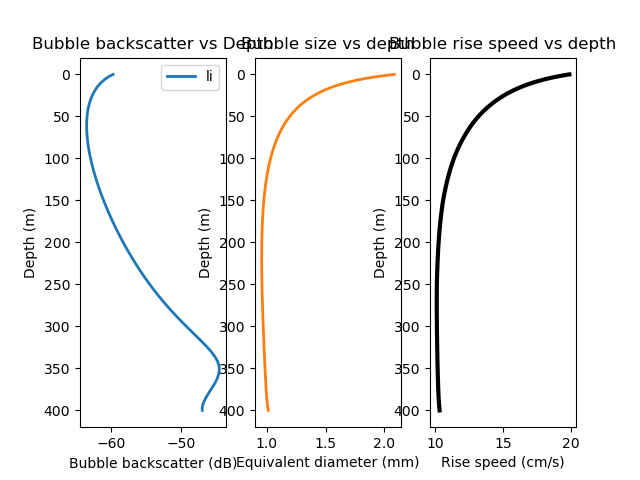

In [16]:
bs = []
bs2 = []
freq = 38e3
e=1

Z = data[:, var_names.index('Particle z-coordinate (m)')][::e]
D = data[:,var_names.index('Particle diameter (m)')][::e]
S = data[:,var_names.index('Slip velocity (m/s)')][::e]

for d,z in tqdm(zip(D,Z) ,total=len(D)):
    #bs.append(10*np.log10(gasbubbles.backscatter.echosms_wrapper.calculate_sigma_bs_mss(freq, d/2,z)))
    bs2.append(10*np.log10(gasbubbles.backscatter.li.calculate_sigma_bs(freq, d/2,z)))
    

plt.close('comp2')
fig,(ax1,ax2,ax3) = plt.subplots(num='comp2', ncols=3)
#ax1.plot(bs, Z, lw=2, label = 'echosms')
ax1.plot(bs2, Z, lw=2, label = 'li')
ax1.set(xlabel='Bubble backscatter (dB)', ylabel='Depth (m)',
              title='Bubble backscatter vs Depth')
ax1.legend()

ax1.invert_yaxis()

ax2.plot(1e3 * D, Z, lw=2, c='tab:orange')
ax2.invert_yaxis()
ax2.set(xlabel='Equivalent diameter (mm)', ylabel='Depth (m)',
              title='Bubble size vs depth')

ax3.plot(1e2 * S, Z, lw=3, c='black')
ax3.invert_yaxis()
ax3.set(xlabel='Rise speed (cm/s)', ylabel='Depth (m)',
              title='Bubble rise speed vs depth')